In [ ]:
# --- Personal files --- #
# Append src path
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))
from models.resnet50 import build_model
import utils
import classification

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

In [23]:
dataset_path = PROJECT_ROOT / "data"
# --- Load splits --- #
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "validation",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
)

# --- Inspect class mapping --- #
class_names = train_dataset.class_names
class_to_idx = {name: i for i, name in enumerate(class_names)}

# --- Normalize datasets --- #
# train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
# validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))
# test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))


print("Class mapping:", class_to_idx)

# Inspect first batch
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Batch size:", labels.shape)


Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Class mapping: {'Albrecht_Durer': 0, 'Boris_Kustodiev': 1, 'Camille_Pissarro': 2, 'Childe_Hassam': 3, 'Claude_Monet': 4, 'Edgar_Degas': 5, 'Eugene_Boudin': 6, 'Gustave_Dore': 7, 'Ilya_Repin': 8, 'Ivan_Aivazovsky': 9, 'Ivan_Shishkin': 10, 'John_Singer_Sargent': 11, 'Marc_Chagall': 12, 'Martiros_Saryan': 13, 'Nicholas_Roerich': 14, 'Pablo_Picasso': 15, 'Paul_Cezanne': 16, 'Pierre_Auguste_Renoir': 17, 'Pyotr_Konchalovsky': 18, 'Raphael_Kirchner': 19, 'Rembrandt': 20, 'Salvador_Dali': 21, 'Vincent_van_Gogh': 22}
Images shape: (32, 224, 224, 3)
Batch size: (32,)


In [ ]:
model = build_model(num_classes=23, trainable_layers=30)

# --- Compile --- #
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=[],
)

# --- Train --- #
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
)

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 259s 879ms/step - accuracy: 0.2777 - loss: 7.5848 - val_accuracy: 0.5166 - val_loss: 1.6546
Epoch 2/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 257s 882ms/step - accuracy: 0.3960 - loss: 2.0877 - val_accuracy: 0.5201 - val_loss: 1.6173
Epoch 3/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 263s 901ms/step - accuracy: 0.4396 - loss: 1.9280 - val_accuracy: 0.5361 - val_loss: 1.5945
Epoch 4/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 275s 941ms/step - accuracy: 0.4579 - loss: 1.8576 - val_accuracy: 0.5979 - val_loss: 1.3508
Epoch 5/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.4801 - loss: 1.7979 - val_accuracy: 0.5763 - val_loss: 1.4527
Epoch 6/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 283s 969ms/step - accuracy: 0.4873 - loss: 1.7383 - val_accuracy: 0.5778 - val_loss: 1.4283
Epoch 7/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 290s 994ms/step - accuracy: 0.4832 - loss: 1.7558 - val_accuracy: 0.5848 - val_loss: 1.4513
Epoch 8/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 291s 996ms/step - accuracy: 0.5110 - lo

In [ ]:
model.summary()

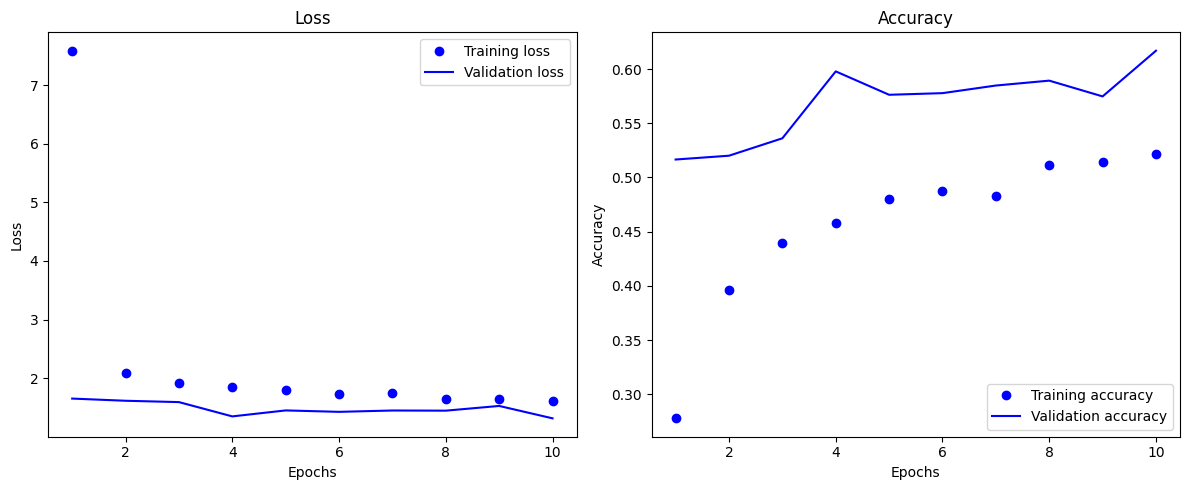

In [27]:
import matplotlib.pyplot as plt

history_dict = history.history

# Loss metrics
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
# Accuracy metrics
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
